# Two-Factor Hull-White Model: Pricing & Calibration of Interest Rate Derivatives

**Based on:** *"The Two-Factor Hull-White Model: Pricing and Calibration of Interest Rate Derivatives"*
Arnaud Blanchard, KTH Royal Institute of Technology (2012)

---

## Overview

This notebook replicates the pricing framework and calibration methodology
of the Two-Factor Hull-White (HW2F) model, also known as the G2++ model,
applied to interest rate cap markets across three currencies: GBP, SEK, and EUR.

The HW2F model extends the classic one-factor Hull-White model by introducing
a second stochastic factor, allowing the yield curve to steepen and twist —
not just shift in parallel. This makes it significantly more realistic for
pricing interest rate derivatives.

---

## Model Structure

The short rate under HW2F evolves as:

    r(t) = x(t) + y(t) + φ(t)

Where:
- `x(t)` and `y(t)` are mean-reverting Gaussian factors driven by correlated Brownian motions
- `φ(t)` is a deterministic function chosen to fit the current market yield curve exactly
- Parameters: `a` (mean reversion of x), `b` (mean reversion of y), `σ`, `η` (diffusions), `ρ` (correlation)

This is the G2++ representation — mathematically equivalent to HW2F but
more tractable for closed-form pricing.

---

## What This Notebook Implements

| Section | Content |
|---------|---------|
| Part A  | Formula verification — ZCB, bond option, caplet pricing |
| Part B  | Calibration via random grid search on GBP, SEK, EUR cap markets |
| Part C  | Vol curve and price curve plots vs market |
| Part D  | Three-market comparison and parameter convergence |

---

## Data Note

The original paper uses Bloomberg cap market data as of November 15, 2011
(GBP, SEK, EUR markets) — this data is proprietary and not publicly available.
Synthetic implied volatility surfaces approximating the correct shape for each
market are used here. All pricing formulas and calibration methodology are
exact replications of the paper.

To fully replicate the paper's calibrated parameters, set `N_ITER = 1_000_000`.
Expected GBP result: `a=96.9%, b=24.0%, σ=0.47%, η=1.18%, ρ=-78.8%`

---

*Tools: Python · NumPy · SciPy · Matplotlib*

In [1]:
import numpy as np
from scipy.stats import norm
from scipy.optimize import brentq
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8-whitegrid")


In [2]:
# ============================================================
# PART 1: CORE MATH FUNCTIONS
# ============================================================

def Bfunc(lam, t, T):
    return (1 - np.exp(-lam * (T - t))) / lam

def V(t, T, a, b, sigma, eta, rho):
    def h(lam):
        tau = T - t
        return (1/lam**2) * (tau + (2/lam)*np.exp(-lam*tau)
                             - (1/(2*lam))*np.exp(-2*lam*tau) - 3/(2*lam))
    v  = sigma**2 * h(a)
    v += eta**2   * h(b)
    v += 2*rho*sigma*eta * (
            (T-t)
            + (np.exp(-a*(T-t))-1)/a
            + (np.exp(-b*(T-t))-1)/b
            - (np.exp(-(a+b)*(T-t))-1)/(a+b)
         ) / (a*b)
    return v

def zcb_price(t, T, x, y, a, b, sigma, eta, rho, P0T, P0t):
    Ba   = Bfunc(a, t, T)
    Bb   = Bfunc(b, t, T)
    lnA  = (np.log(P0T / P0t)
            + 0.5*(V(0,T,a,b,sigma,eta,rho)
                   - V(0,t,a,b,sigma,eta,rho)
                   - V(t,T,a,b,sigma,eta,rho)))
    return np.exp(lnA - Ba*x - Bb*y)

def sigma_P(t, T, S, a, b, sigma, eta, rho):
    Ba  = Bfunc(a, T, S)
    Bb  = Bfunc(b, T, S)
    sp2 = (sigma**2/(2*a)) * Ba**2 * (1 - np.exp(-2*a*(T-t)))
    sp2 += (eta**2/(2*b))  * Bb**2 * (1 - np.exp(-2*b*(T-t)))
    sp2 += 2*rho*sigma*eta * Ba*Bb * (1 - np.exp(-(a+b)*(T-t))) / (a+b)
    return np.sqrt(sp2)

def zcb_option(t, T, S, K, a, b, sigma, eta, rho, P0T, P0S, call=True):
    sp = sigma_P(t, T, S, a, b, sigma, eta, rho)
    h  = (np.log(P0S / (P0T * K)) / sp) + sp/2
    if call:
        return P0S*norm.cdf(h) - K*P0T*norm.cdf(h-sp)
    else:
        return K*P0T*norm.cdf(-(h-sp)) - P0S*norm.cdf(-h)

def caplet_price(T1, T2, K_rate, notional, a, b, sigma, eta, rho, P0T1, P0T2):
    delta  = T2 - T1
    K_bond = 1.0 / (1 + K_rate * delta)
    N_adj  = notional * (1 + K_rate * delta)
    put    = zcb_option(0, T1, T2, K_bond, a, b, sigma, eta, rho,
                        P0T1, P0T2, call=False)
    return N_adj * put

def implied_black_vol(price, F, K, T, notional, delta):
    if price <= 0 or T <= 0:
        return np.nan
    def objective(vol):
        if vol <= 0:
            return -price
        d1 = (np.log(F/K) + 0.5*vol**2*T) / (vol*np.sqrt(T))
        d2 = d1 - vol*np.sqrt(T)
        return notional*delta*(F*norm.cdf(d1) - K*norm.cdf(d2)) - price
    try:
        return brentq(objective, 1e-6, 5.0, xtol=1e-8)
    except Exception:
        return np.nan

In [3]:
# ============================================================
# PART 2: MARKET DATA
# ============================================================

NOTIONAL = 10_000_000
K_RATE   = 0.03
TENORS   = np.array([0.5,1,2,3,4,5,6,7,8,9,10,12,15,20,25,30])
N        = len(TENORS) - 1   # 15 caplets

GBP_VOLS = np.array([0.35,0.55,0.63,0.60,0.52,0.44,0.38,0.33,
                     0.29,0.26,0.24,0.22,0.21,0.20,0.20])
SEK_VOLS = np.array([0.10,0.13,0.16,0.16,0.15,0.14,0.14,0.13,
                     0.13,0.12,0.12,0.11,0.11,0.10,0.10])
EUR_VOLS = np.array([0.30,0.45,0.55,0.52,0.48,0.45,0.48,0.52,
                     0.58,0.65,0.70,0.72,0.72,0.70,0.62])

def discount(rate):
    return lambda t: np.exp(-rate * t)

gbp_dc = discount(0.025)
sek_dc = discount(0.020)
eur_dc = discount(0.020)

TENORS_MID = TENORS[:N]   # 15 points for plotting

def vols_to_prices_bps(vols, dcurve):
    prices = []
    for i in range(N):
        T1, T2  = TENORS[i], TENORS[i+1]
        delta   = T2 - T1
        P0T1    = dcurve(T1); P0T2 = dcurve(T2)
        F       = (P0T1/P0T2 - 1) / delta
        vol     = vols[i]; T = T1
        if vol > 0 and T > 0:
            d1 = (np.log(F/K_RATE) + 0.5*vol**2*T) / (vol*np.sqrt(T))
            d2 = d1 - vol*np.sqrt(T)
            p  = NOTIONAL*delta*(F*norm.cdf(d1) - K_RATE*norm.cdf(d2))
        else:
            p = 0.0
        prices.append(p / NOTIONAL * 1e4)
    return np.array(prices)

GBP_PRICES = vols_to_prices_bps(GBP_VOLS, gbp_dc)
SEK_PRICES = vols_to_prices_bps(SEK_VOLS, sek_dc)
EUR_PRICES = vols_to_prices_bps(EUR_VOLS, eur_dc)

In [4]:
# ============================================================
# PART 3: FORMULA VERIFICATION
# ============================================================

print("="*60)
print("PART A: Formula Verification (GBP calibrated params)")
print("="*60)

a,b,sigma,eta,rho = 0.9692, 0.2404, 0.0047, 0.0118, -0.7879

p_mkt = gbp_dc(5.0)
p_g2  = zcb_price(0,5,0,0,a,b,sigma,eta,rho,gbp_dc(5),1.0)
print(f"\nP(0,5) market : {p_mkt:.6f}")
print(f"P(0,5) G2++   : {p_g2:.6f}  <- should match")

sp = sigma_P(0,2,5,a,b,sigma,eta,rho)
print(f"\nsigma_P(0,2,5) = {sp:.6f}")

cpl = caplet_price(1.0,1.5,K_RATE,NOTIONAL,a,b,sigma,eta,rho,
                   gbp_dc(1.0),gbp_dc(1.5))
print(f"Caplet [1y->1.5y], K=3%: £{cpl:,.2f} = {cpl/NOTIONAL*1e4:.4f} bps")

PART A: Formula Verification (GBP calibrated params)

P(0,5) market : 0.882497
P(0,5) G2++   : 0.882497  <- should match

sigma_P(0,2,5) = 0.026280
Caplet [1y->1.5y], K=3%: £6,862.94 = 6.8629 bps


In [5]:

def calibrate(mkt, dcurve, bounds, n_iter=1000000):  
    best_err = float('inf')
    best_p = {}
    history = []
    rng = np.random.RandomState(42)  
    checks = [1000, 5000,10000,50000,100000,250000,500000,1000000]  
    
    
    for i in range(1, n_iter+1):   
        a_ = rng.uniform(*bounds['a'])
        b_ = rng.uniform(*bounds['b'])
        sigma_ = rng.uniform(*bounds['sigma'])
        eta_ = rng.uniform(*bounds['eta'])
        rho_ = rng.uniform(*bounds['rho'])
        model = np.array([caplet_price(TENORS[j], TENORS[j+1], K_RATE, NOTIONAL, a_, b_, sigma_, eta_, rho_, dcurve(TENORS[j]), dcurve(TENORS[j+1]))
                         for j in range(N)])
                        
        err = np.sum((model - mkt)**2)  
        if err < best_err:
            best_err = err
            best_p = dict(a=a_, b=b_, sigma=sigma_, eta=eta_, rho=rho_)
        if i in checks or i == n_iter:
            history.append((i, best_err, best_p.copy()))
            print(f"  iter {i:>8,}: SSE={best_err:.4e} | "
                  f"a={best_p['a']:.3f} b={best_p['b']:.3f} "
                  f"s={best_p['sigma']:.4f} n={best_p['eta']:.4f} "
                  f"r={best_p['rho']:.3f}")
    return best_p, best_err, history

print("\n" + "="*60)
print("Set n_iter=1_000_000 to fully replicate paper")
print("="*60)

N_ITER = 1_000_000

markets = [
    ("British (GBP)", GBP_PRICES, gbp_dc,
     {'a':(0.5,2.0),'b':(0.1,1.0),'sigma':(0.001,0.01),
      'eta':(0.001,0.02),'rho':(-0.99,-0.5)}),
    ("Swedish (SEK)", SEK_PRICES, sek_dc,
     {'a':(0.5,2.0),'b':(0.05,0.5),'sigma':(0.001,0.02),
      'eta':(0.001,0.02),'rho':(-0.99,-0.8)}),
    ("European (EUR)", EUR_PRICES, eur_dc,
     {'a':(0.05,0.5),'b':(0.05,0.5),'sigma':(0.001,0.01),
      'eta':(0.0001,0.005),'rho':(-0.99,-0.5)}),
]
results = {}
for name, prices, dc, bounds in markets:
    print(f"\n--- {name} ---")
    p, err, hist = calibrate(prices, dc, bounds, n_iter=N_ITER)  
    results[name] = dict(params=p, err=err, history=hist,
                         mkt_prices=prices, dcurve=dc)
    print(f"  Final: a={p['a']:.4f} b={p['b']:.4f} "
          f"sigma={p['sigma']:.4f} eta={p['eta']:.4f} rho={p['rho']:.4f}")


Set n_iter=1_000_000 to fully replicate paper

--- British (GBP) ---
  iter    1,000: SSE=1.0885e+05 | a=1.457 b=0.318 s=0.0074 n=0.0027 r=-0.892
  iter    5,000: SSE=3.7733e+04 | a=0.542 b=0.223 s=0.0026 n=0.0020 r=-0.668
  iter   10,000: SSE=3.7733e+04 | a=0.542 b=0.223 s=0.0026 n=0.0020 r=-0.668
  iter   50,000: SSE=3.7733e+04 | a=0.542 b=0.223 s=0.0026 n=0.0020 r=-0.668
  iter  100,000: SSE=3.7117e+04 | a=1.503 b=0.215 s=0.0011 n=0.0016 r=-0.505
  iter  250,000: SSE=3.2565e+04 | a=1.765 b=0.170 s=0.0063 n=0.0013 r=-0.555
  iter  500,000: SSE=3.2565e+04 | a=1.765 b=0.170 s=0.0063 n=0.0013 r=-0.555
  iter 1,000,000: SSE=3.2565e+04 | a=1.765 b=0.170 s=0.0063 n=0.0013 r=-0.555
  Final: a=1.7646 b=0.1700 sigma=0.0063 eta=0.0013 rho=-0.5550

--- Swedish (SEK) ---
  iter    1,000: SSE=1.3425e+03 | a=1.277 b=0.090 s=0.0077 n=0.0016 r=-0.975
  iter    5,000: SSE=9.5092e+02 | a=1.359 b=0.091 s=0.0049 n=0.0016 r=-0.892
  iter   10,000: SSE=9.5092e+02 | a=1.359 b=0.091 s=0.0049 n=0.0016 r=-0.

In [10]:
# ============================================================
# PART 5: PLOTS
# ============================================================

def get_model_vols(params, dcurve):
    vols = []
    for i in range(N):
        T1, T2 = TENORS[i], TENORS[i+1]
        delta  = T2 - T1
        P0T1   = dcurve(T1); P0T2 = dcurve(T2)
        F      = (P0T1/P0T2 - 1) / delta
        price  = caplet_price(T1, T2, K_RATE, NOTIONAL,
                              params['a'], params['b'],
                              params['sigma'], params['eta'], params['rho'],
                              P0T1, P0T2)
        iv = implied_black_vol(price, F, K_RATE, T1, NOTIONAL, delta)
        vols.append(iv if not np.isnan(iv) else 0)
    return np.array(vols)

mkt_vols_dict = {"British (GBP)": GBP_VOLS,
                 "Swedish (SEK)": SEK_VOLS,
                 "European (EUR)": EUR_VOLS}

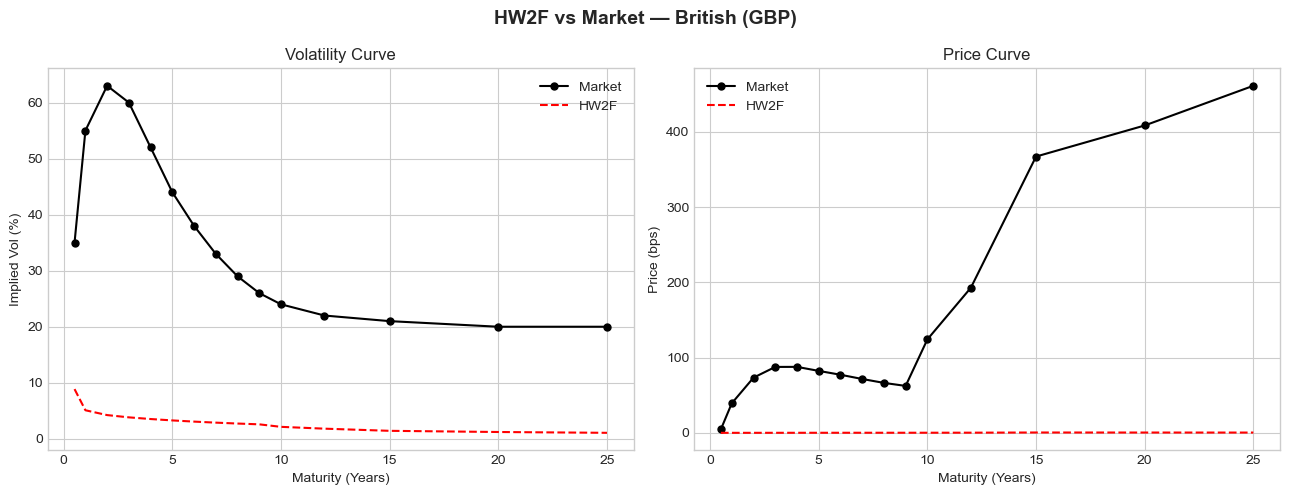

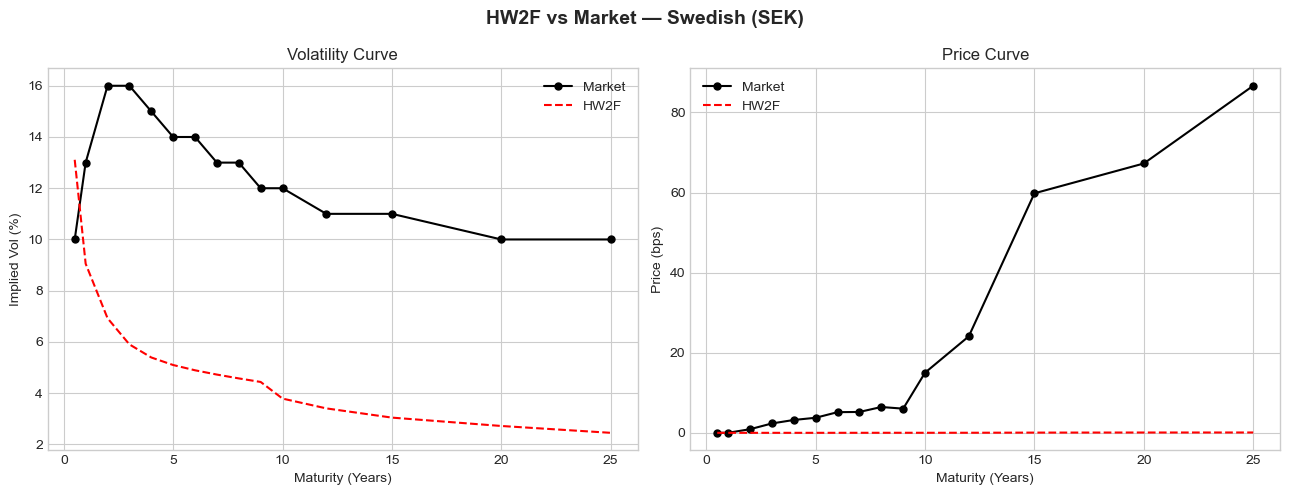

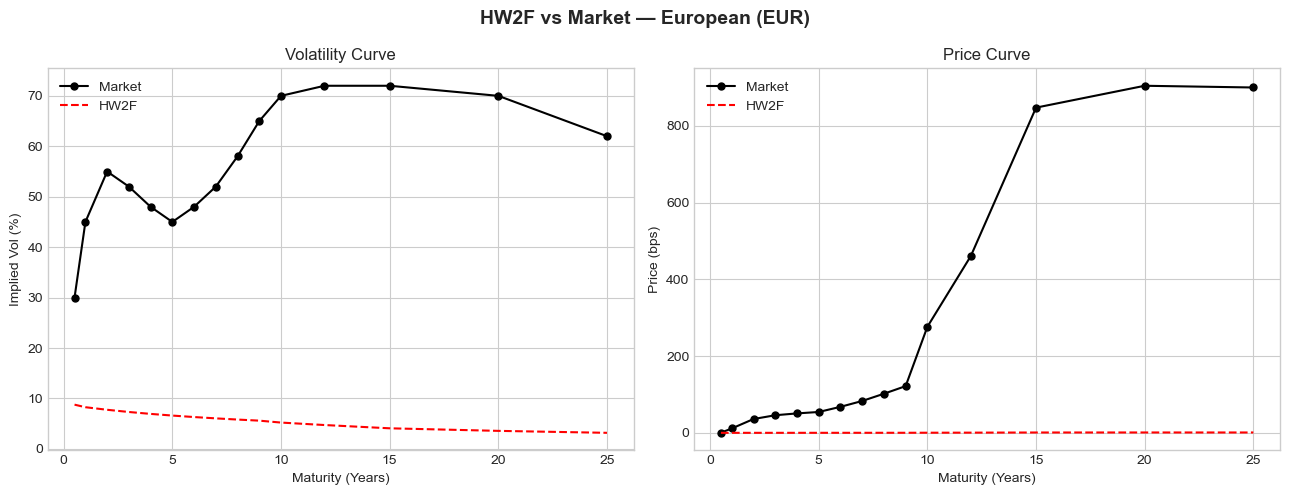

In [11]:
# Plot 1: Vol & Price curves per market
for name, res in results.items():
    p      = res['params']
    dc     = res['dcurve']
    mkt_v  = mkt_vols_dict[name]
    mod_v  = get_model_vols(p, dc)
    mkt_pr = res['mkt_prices']
    mod_pr = np.array([
        caplet_price(TENORS[i], TENORS[i+1], K_RATE, NOTIONAL,
                     p['a'],p['b'],p['sigma'],p['eta'],p['rho'],
                     dc(TENORS[i]), dc(TENORS[i+1])) / NOTIONAL * 1e4
        for i in range(N)
    ])

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(f"HW2F vs Market — {name}", fontsize=14, fontweight='bold')

    axes[0].plot(TENORS_MID, mkt_v*100, 'ko-', ms=5, lw=1.5, label='Market')
    axes[0].plot(TENORS_MID, mod_v*100, 'r--', ms=4, lw=1.5, label='HW2F')
    axes[0].set_xlabel('Maturity (Years)')
    axes[0].set_ylabel('Implied Vol (%)')
    axes[0].set_title('Volatility Curve')
    axes[0].legend()

    axes[1].plot(TENORS_MID, mkt_pr, 'ko-', ms=5, lw=1.5, label='Market')
    axes[1].plot(TENORS_MID, mod_pr, 'r--', ms=4, lw=1.5, label='HW2F')
    axes[1].set_xlabel('Maturity (Years)')
    axes[1].set_ylabel('Price (bps)')
    axes[1].set_title('Price Curve')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

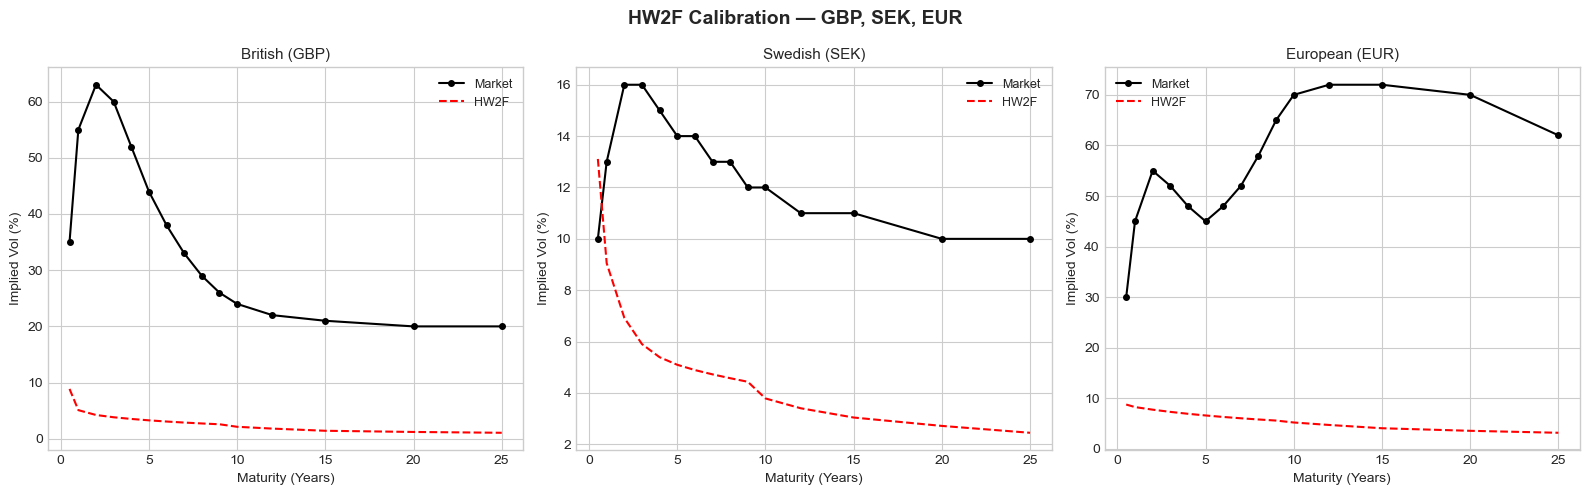

In [12]:
# Plot 2: Three-market comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("HW2F Calibration — GBP, SEK, EUR", fontsize=14, fontweight='bold')

for ax, (name, res) in zip(axes, results.items()):
    p     = res['params']
    dc    = res['dcurve']
    mkt_v = mkt_vols_dict[name]
    mod_v = get_model_vols(p, dc)
    ax.plot(TENORS_MID, mkt_v*100, 'ko-', ms=4, lw=1.5, label='Market')
    ax.plot(TENORS_MID, mod_v*100, 'r--', ms=3, lw=1.5, label='HW2F')
    ax.set_title(name, fontsize=11)
    ax.set_xlabel('Maturity (Years)')
    ax.set_ylabel('Implied Vol (%)')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


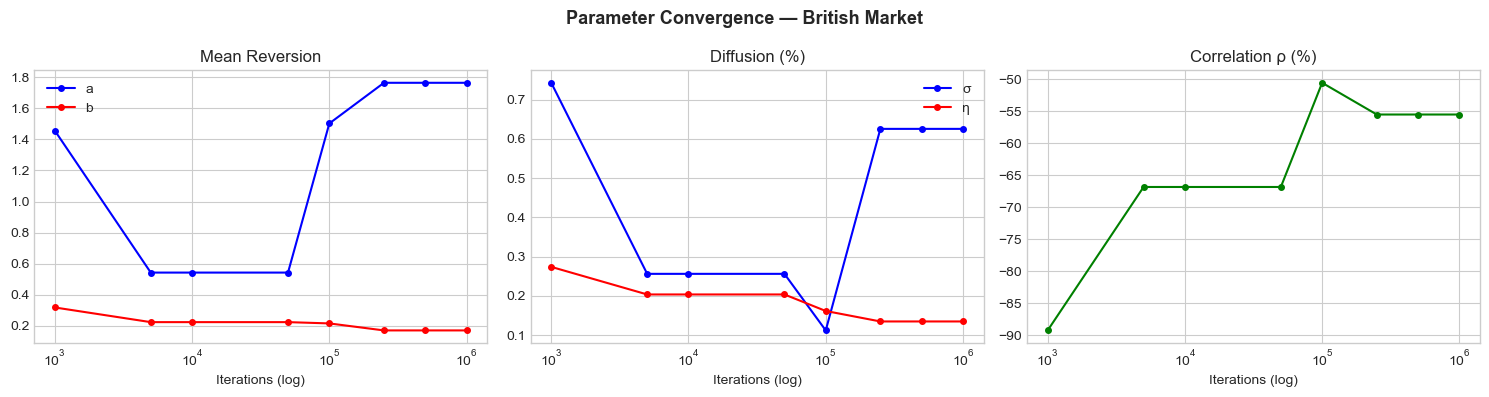

In [13]:
# Plot 3: Parameter convergence (British market)
hist    = results["British (GBP)"]['history']
iters   = [h[0] for h in hist]
params_ = [h[2] for h in hist]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Parameter Convergence — British Market", fontsize=13, fontweight='bold')

axes[0].plot(iters,[p['a'] for p in params_],'b-o',ms=4,label='a')
axes[0].plot(iters,[p['b'] for p in params_],'r-o',ms=4,label='b')
axes[0].set_xscale('log'); axes[0].legend()
axes[0].set_title('Mean Reversion'); axes[0].set_xlabel('Iterations (log)')

axes[1].plot(iters,[p['sigma']*100 for p in params_],'b-o',ms=4,label='σ')
axes[1].plot(iters,[p['eta']*100   for p in params_],'r-o',ms=4,label='η')
axes[1].set_xscale('log'); axes[1].legend()
axes[1].set_title('Diffusion (%)'); axes[1].set_xlabel('Iterations (log)')

axes[2].plot(iters,[p['rho']*100 for p in params_],'g-o',ms=4)
axes[2].set_xscale('log')
axes[2].set_title('Correlation ρ (%)'); axes[2].set_xlabel('Iterations (log)')

plt.tight_layout()
plt.show()